# Lab 05: Redes Neuronales en PyTorch
**Cuadernillo 2: Clasificación (Regresión Logística con MLP)**

##Estudiante:
* Delgado Ramos Jorge Luis

In [1]:
# LIBRERÍAS
import os
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# PREPROCESAMIENTO PARA EL DATASET
**Dataset:** NSL-KDD (Detección de Intrusiones en Redes)

El archivo original `KDDTrain+.txt` carece de una fila de encabezados (headers). Si se carga directamente, Pandas tomará la primera fila de datos como los nombres de las columnas, perdiendo un registro y desorganizando los tipos de datos. Para evitar esto, se define manualmente un vector con los 43 nombres exactos de las características y se asignan durante la lectura.

In [3]:
# DEFINICIÓN DE COLUMNAS Y CARGA DE DATOS
# El dataset no tiene nombres de columnas, debemos asignarlos manualmente
nombres_columnas = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'class', 'difficulty'
]

ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/SIS-420/Laboratorio 05/Lab_05_RN_Pytorch_Cuad_02/KDDTrain+.txt'
datos = pd.read_csv(ruta_dataset, header=None, names=nombres_columnas)

print(f"Dimensiones del dataset original: m={datos.shape[0]} filas, n_total={datos.shape[1]} columnas")

Dimensiones del dataset original: m=125973 filas, n_total=43 columnas


## Limpieza de Datos y Binarización del Target
En esta etapa preparamos el dataset específicamente para la Regresión Logística Binaria, asegurando la integridad del modelo.

1. **Prevención de Data Leakage (Fuga de Información):** Se elimina la característica `difficulty`. Esta columna no representa un dato capturado del tráfico de red, sino un metadato asignado por los autores del dataset para calificar la dificultad del registro. Incluirla sesgaría el modelo de forma artificial.
2. **Transformación Binaria de la Variable Dependiente ($y$):** La variable `class` contiene más de 20 subcategorías de ciberataques (ej. DoS, Probe, R2L). Dado que el objetivo es implementar una clasificación binaria clásica (probabilidades entre 0 y 1 mediante la función Sigmoide), se agrupan todos los ataques bajo la etiqueta `1` (Intrusión) y el tráfico seguro bajo la etiqueta `0` (Normal).

In [4]:
# Eliminar la columna de metadatos 'difficulty' para evitar fuga de información
if 'difficulty' in datos.columns:
    datos_limpios = datos.drop('difficulty', axis=1)
else:
    datos_limpios = datos.copy()

# Binarizar la columna objetivo 'class' (y)
datos_limpios['class'] = datos_limpios['class'].apply(lambda x: 0 if x == 'normal' else 1)

print("Distribución de clases después de la binarización:")
print("0 = Tráfico Normal | 1 = Ataque")
print(datos_limpios['class'].value_counts())

print(f"\nNuevas dimensiones: m={datos_limpios.shape[0]} filas, n={datos_limpios.shape[1]} columnas")

Distribución de clases después de la binarización:
0 = Tráfico Normal | 1 = Ataque
class
0    67343
1    58630
Name: count, dtype: int64

Nuevas dimensiones: m=125973 filas, n=42 columnas


## Conversión de Variables Categóricas (Label Encoding)
La Regresión Logística requiere que todos los datos de entrada ($X$) sean puramente numéricos para poder procesarlos mediante la Función Sigmoide. En el análisis de tráfico de red actual, contamos con características en formato de texto: `protocol_type`, `service` y `flag`.

Se aplica la técnica de **Label Encoding** para transformar estos valores categóricos en representaciones numéricas enteras (ej. tcp=1, udp=2).

In [5]:
datos_numericos = datos_limpios.copy()

# Identificamos las columnas de tipo texto (object)
columnas_texto = datos_numericos.select_dtypes(include=['object']).columns
print("Columnas categóricas detectadas:", list(columnas_texto))

codificador = LabelEncoder()

# Transformamos cada columna de texto en números
for columna in columnas_texto:
    datos_numericos[columna] = codificador.fit_transform(datos_numericos[columna])

print("\nVista previa del dataset 100% numérico:")
display(datos_numericos.head(3))

Columnas categóricas detectadas: ['protocol_type', 'service', 'flag']

Vista previa del dataset 100% numérico:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,0
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,0
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,1


## División del Dataset (80/20) y Normalización
Para garantizar que el modelo adquiera capacidad de generalización y no simplemente memorice los datos (overfitting), se divide el dataset mediante la proporción exigida: 80% para entrenamiento (Training) y 20% para pruebas (Testing).

**Justificación:**
1. **División (Train/Test Split):** Se aíslan 20% de los datos de forma aleatoria. Este conjunto no será visto por el modelo durante la optimización de los pesos $\theta$.
2. **Normalización Estricta:** Para evitar "fuga de información" (Data Leakage), el escalado Z-score se calcula **únicamente** utilizando la media ($\mu$) y desviación estándar ($\sigma$) del conjunto de entrenamiento. Luego, estos mismos parámetros se aplican matemáticamente al conjunto de pruebas. Finalmente, se añade el término de intersección ($x_0=1$) a ambas matrices.

In [6]:
# Separación inicial de X y y (de nuestro dataset 100% numérico)
y_completo = datos_numericos['class'].values
X_completo = datos_numericos.drop('class', axis=1).values

# División 80% Entrenamiento / 20% Prueba

# random_state asegura que si corremos esto 100 veces, la división sea siempre la misma
X_train, X_test, y_train, y_test = train_test_split(X_completo, y_completo, test_size=0.20, random_state=42)

m_train = len(y_train)
m_test = len(y_test)

print("--- VERIFICACIÓN DE RESTRICCIONES (80/20) ---")
print(f"Total de datos originales: {len(y_completo)}")
print(f"Datos para Entrenar (80%): {m_train}")
print(f"Datos para Pruebas  (20%): {m_test}\n")

# 3. Función de Normalización (Protegida)
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1 # Protección contra NaN
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# NORMALIZACIÓN ESTRICTA (Sin fuga de información)

# Calculamos mu y sigma SOLO del 80% de entrenamiento
X_train_norm, mu_train, sigma_train = normalizarCaracteristicas(X_train)

# Aplicamos ese mismo mu y sigma al 20% de pruebas
X_test_norm = (X_test - mu_train) / sigma_train

# Añadir la columna de unos a ambas matrices
X_train_listo = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_listo = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print(f"Forma de X_train_listo: {X_train_listo.shape}")
print(f"Forma de X_test_listo:  {X_test_listo.shape}")

--- VERIFICACIÓN DE RESTRICCIONES (80/20) ---
Total de datos originales: 125973
Datos para Entrenar (80%): 100778
Datos para Pruebas  (20%): 25195

Forma de X_train_listo: (100778, 42)
Forma de X_test_listo:  (25195, 42)


## 1. Integración de Datos Divididos (80/20) y DataLoaders
En este cuadernillo, respetamos la división de datos realizada en el preprocesamiento del Laboratorio 03. Contamos con conjuntos de entrenamiento (`X_train_listo`) y prueba (`X_test_listo`) ya purificados, binarizados y codificados.

**Ventajas de este enfoque:**
1. **Prevención de Sesgos:** Al pasar los datos ya divididos a PyTorch, garantizamos que los parámetros estadísticos del entrenamiento no se contaminen con la información del conjunto de prueba.
2. **Evaluación Realista:** Creamos un `train_loader` para el bucle de entrenamiento y un `test_loader` separado. Este último se utilizará exclusivamente para medir la precisión final del modelo, simulando un entorno de producción con datos inéditos.

La clase puente `ClasificacionDatasetLimpio` se encarga de transformar estas matrices en tensores, asegurando que la etiqueta objetivo ($y$) tenga el formato de columna requerido por PyTorch.

In [7]:
# EL PUENTE PARA DATOS DIVIDIDOS

class ClasificacionDatasetLimpio(Dataset):
    def __init__(self, X_limpio, y_limpio):
        # Convertimos a float32 y nos aseguramos de que sean arreglos de Numpy
        X_numpy = np.array(X_limpio, dtype=np.float32)
        y_numpy = np.array(y_limpio, dtype=np.float32)

        # PROTECCIÓN: Si tu preprocesamiento añadió la columna de 1s (sesgo), la quitamos
        if np.all(X_numpy[:, 0] == 1.0):
            X_numpy = X_numpy[:, 1:]

        self.X = torch.tensor(X_numpy, dtype=torch.float32)
        # Reshape para que y sea (N, 1)
        self.y = torch.tensor(y_numpy, dtype=torch.float32).view(-1, 1)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# USAMOS LAS VARIABLES DEL LAB 03 (Entrenamiento y Prueba)

# 1. Creamos los objetos Dataset
train_dataset = ClasificacionDatasetLimpio(X_train_listo, y_train)
test_dataset = ClasificacionDatasetLimpio(X_test_listo, y_test)

# 2. Creamos los DataLoaders independientes
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print(f"Configuración exitosa:")
print(f"-> Muestras para Entrenamiento: {len(train_dataset)}")
print(f"-> Muestras para Validación:    {len(test_dataset)}")
print(f"-> Características de entrada:  {train_dataset.X.shape[1]}")

Configuración exitosa:
-> Muestras para Entrenamiento: 100778
-> Muestras para Validación:    25195
-> Características de entrada:  41


## 2. Arquitectura de la Red para Ciberseguridad
Definimos un Perceptrón Multicapa (MLP) diseñado para la detección de anomalías en tráfico de red. La arquitectura es dinámica: se auto-ajusta al número de características generadas tras el One-Hot Encoding del Laboratorio 03.

Utilizamos capas densas (`nn.Linear`) con funciones de activación `ReLU` para permitir que el modelo aprenda las complejas fronteras de decisión necesarias para distinguir entre tráfico normal y ataques de red. La salida consiste en un único logit que será procesado por la función de pérdida `BCEWithLogitsLoss`.

In [8]:
# MODELO NEURONAL DINÁMICO

class RedCiberseguridad(nn.Module):
    def __init__(self, input_size):
        super(RedCiberseguridad, self).__init__()
        self.capa1 = nn.Linear(input_size, 64)
        self.relu1 = nn.ReLU()
        self.capa2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.capa_salida = nn.Linear(32, 1)

    def forward(self, x):
        out = self.relu1(self.capa1(x))
        out = self.relu2(self.capa2(out))
        return self.capa_salida(out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo_clf = RedCiberseguridad(input_size=train_dataset.X.shape[1]).to(device)

criterio_clf = nn.BCEWithLogitsLoss()
optimizador_clf = torch.optim.Adam(modelo_clf.parameters(), lr=0.001)

print(f"Red Neuronal lista y sincronizada en: {device}")

Red Neuronal lista y sincronizada en: cpu


## 3. Bucle de Entrenamiento (Clasificación Binaria)
Durante el entrenamiento, la red neuronal procesa exclusivamente los lotes del `train_loader`. En cada iteración, se evalúa la función de pérdida `BCEWithLogitsLoss`, ideal para clasificación binaria ya que combina matemáticamente la función Sigmoide y la Entropía Cruzada en una sola operación, mitigando problemas de inestabilidad numérica.

Al finalizar cada época, registramos tanto la pérdida como la precisión de clasificación (aplicando explícitamente la función Sigmoide a los logits para obtener probabilidades y redondeando al entero más cercano: `0` o `1`).

Iniciando el entrenamiento (Solo datos de entrenamiento)...
Época [10/100] | Pérdida: 0.0142 | Precisión: 99.50%
Época [20/100] | Pérdida: 0.0104 | Precisión: 99.63%
Época [30/100] | Pérdida: 0.0083 | Precisión: 99.71%
Época [40/100] | Pérdida: 0.0073 | Precisión: 99.74%
Época [50/100] | Pérdida: 0.0065 | Precisión: 99.76%
Época [60/100] | Pérdida: 0.0059 | Precisión: 99.79%
Época [70/100] | Pérdida: 0.0059 | Precisión: 99.78%
Época [80/100] | Pérdida: 0.0055 | Precisión: 99.79%
Época [90/100] | Pérdida: 0.0055 | Precisión: 99.80%
Época [100/100] | Pérdida: 0.0049 | Precisión: 99.81%


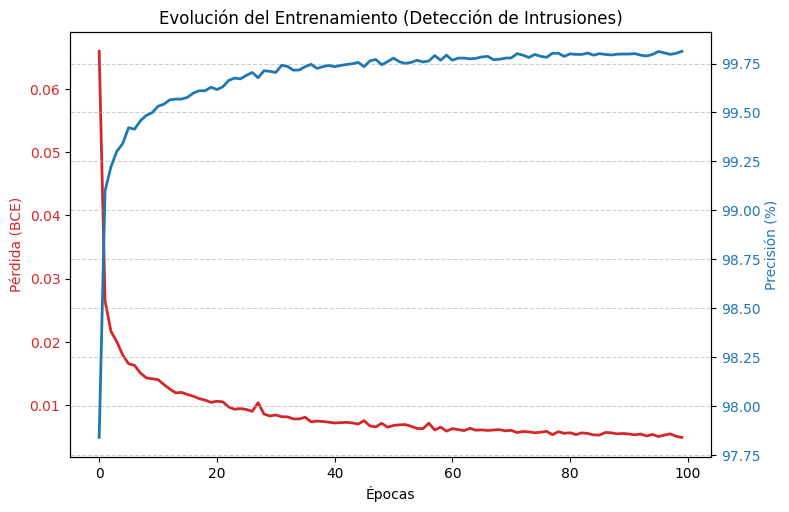

In [9]:
# ENTRENAMIENTO DEL MODELO DE CIBERSEGURIDAD

num_epochs = 100
historial_perdida = []
historial_precision = []

print("Iniciando el entrenamiento (Solo datos de entrenamiento)...")

for epoch in range(num_epochs):
    modelo_clf.train() # Nos aseguramos de que esté en modo entrenamiento
    perdida_acumulada = 0.0
    correctos = 0
    total = 0

    # Solo usamos el DataLoader de entrenamiento
    for entradas, etiquetas in train_loader:
        entradas = entradas.to(device)
        etiquetas = etiquetas.to(device)

        # 1. Forward Pass
        logits = modelo_clf(entradas)
        perdida = criterio_clf(logits, etiquetas)

        # 2. Backward Pass y Optimización
        optimizador_clf.zero_grad()
        perdida.backward()
        optimizador_clf.step()

        perdida_acumulada += perdida.item()

        # 3. Cálculo de precisión del lote
        probabilidades = torch.sigmoid(logits)
        predicciones = torch.round(probabilidades)
        correctos += (predicciones == etiquetas).sum().item()
        total += etiquetas.size(0)

    # Métricas de la época
    perdida_promedio = perdida_acumulada / len(train_loader)
    precision_epoca = (correctos / total) * 100

    historial_perdida.append(perdida_promedio)
    historial_precision.append(precision_epoca)

    if (epoch+1) % 10 == 0:
        print(f'Época [{epoch+1}/{num_epochs}] | Pérdida: {perdida_promedio:.4f} | Precisión: {precision_epoca:.2f}%')

# Gráficas Duales
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida (BCE)', color=color)
ax1.plot(historial_perdida, color=color, linewidth=2, label='Pérdida')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Precisión (%)', color=color)
ax2.plot(historial_precision, color=color, linewidth=2, label='Precisión')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Evolución del Entrenamiento (Detección de Intrusiones)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 4. Persistencia (Checkpoints) y Validación en el Test Set
Para concluir y asegurar la integridad del modelo para un entorno de producción, guardamos los pesos optimizados en un archivo `.pth`.

La verdadera prueba de fuego de cualquier modelo de Machine Learning es su capacidad de generalización. Por ello, instanciamos la red neuronal recuperada y utilizamos el `test_loader` (el 20% de datos inéditos apartados en el Laboratorio 03) para evaluar su efectividad real. Finalmente, extraemos un paquete de red aleatorio y visualizamos el veredicto de la inteligencia artificial.

In [10]:
# CHECKPOINT Y EVALUACIÓN FINAL DE PRODUCCIÓN

# 1. GUARDAR EL MODELO
ruta_modelo_clf = 'modelo_ciberseguridad_lab05.pth'
torch.save(modelo_clf.state_dict(), ruta_modelo_clf)
print(f"Modelo guardado en: {ruta_modelo_clf}")

# 2. CARGAR EL MODELO PARA INFERENCIA
print("\nRecuperando modelo desde el Checkpoint...")
modelo_recuperado = RedCiberseguridad(input_size=train_dataset.X.shape[1]).to(device)
modelo_recuperado.load_state_dict(torch.load(ruta_modelo_clf))
modelo_recuperado.eval() # Modo evaluación (apaga cálculos de gradientes)

# 3. EVALUACIÓN MASIVA EN EL TEST SET (20% DE DATOS INÉDITOS)
print("Evaluando contra el conjunto de prueba (Test Set)...")
correctos_test = 0
total_test = 0

with torch.no_grad():
    for entradas, etiquetas in test_loader:
        entradas = entradas.to(device)
        etiquetas = etiquetas.to(device)

        logits = modelo_recuperado(entradas)
        probabilidades = torch.sigmoid(logits)
        predicciones = torch.round(probabilidades)

        correctos_test += (predicciones == etiquetas).sum().item()
        total_test += etiquetas.size(0)

precision_test = (correctos_test / total_test) * 100
print(f"==================================================")
print(f"PRECISIÓN GLOBAL EN DATOS DE PRUEBA: {precision_test:.2f}%")
print(f"==================================================")

# 4. PREDICCIÓN INDIVIDUAL DE MUESTRA
with torch.no_grad():
    idx_prueba = np.random.randint(0, len(test_dataset))
    muestra_x = test_dataset.X[idx_prueba].unsqueeze(0).to(device)
    etiqueta_real = test_dataset.y[idx_prueba].item()

    logit_pred = modelo_recuperado(muestra_x)
    prob_pred = torch.sigmoid(logit_pred).item()
    clase_predicha = 1 if prob_pred >= 0.5 else 0

    estado_real = "Ataque (1)" if etiqueta_real == 1 else "Normal (0)"
    estado_predicho = "Ataque (1)" if clase_predicha == 1 else "Normal (0)"

    print(f"\n--- INSPECCIÓN DE PAQUETE DE RED ALEATORIO ---")
    print(f"Estado REAL del paquete:      {estado_real}")
    print(f"Probabilidad de ser Ataque:   {prob_pred * 100:.2f}%")
    print(f"Veredicto de la Red Neuronal: {estado_predicho}")

    if int(etiqueta_real) == clase_predicha:
        print("¡La red detectó correctamente el estado del paquete!")
    else:
        print("Falso Positivo/Negativo detectado.")

Modelo guardado en: modelo_ciberseguridad_lab05.pth

Recuperando modelo desde el Checkpoint...
Evaluando contra el conjunto de prueba (Test Set)...
PRECISIÓN GLOBAL EN DATOS DE PRUEBA: 99.66%

--- INSPECCIÓN DE PAQUETE DE RED ALEATORIO ---
Estado REAL del paquete:      Ataque (1)
Probabilidad de ser Ataque:   100.00%
Veredicto de la Red Neuronal: Ataque (1)
¡La red detectó correctamente el estado del paquete!
